# 다이캐스팅 공정 데이터 기반 품질 예측 프로젝트

- 다이캐스팅은 용융 금속을 금형에 고압으로 주입하여 정밀한 제품을 생산하는 공정이다.
- 생산 효율을 높이고 불량품을 낮추기 위해 공정 변수 및 센서 데이터를 분석해서 불량 유형을 자동 예측하는 머신러닝 모델을 개발해야함.
- 실시간 공정 데이터와 품질 검사를 연계하여 품질 예측 시스템을 구축하고자 함.

# 비즈니스 문제 정의

### 현재 상황

- 불량품이 발생해도 육안 검사에 의존하여 판정 기준의 주관성과 검사 속도의 한계로 생산성이 저하됨.
- 불량 발생 원인을 추적하기 힘들어 공정 개선 및 문제 해결이 어려움.
- 공정 데이터와 품질 검사를 효과적으로 매핑하지 못하여 실시간 품질 관리 및 재발 방지 대책이 부족한 상황.

### 분석 목표

- 다이캐스팅 공정 과정에서 발생하는 다양한 불량 유형을 자동으로 예측해주는 머신 러닝 모델 개발
- 공정 데이터와 센서 데이터를 면밀히 분석해 불량 여부와의 관계성 파악
- 불량 발생의 주요 원인을 분석해서 공정의 최적화를 지원
- 실시간 품질 예측 체계를 구축하여 조기 경보 시스템 도입 및 불량률 감소

### 비즈니스 산출물

1) 불량 발생의 주요 원인을 분석하고 이를 시각화하여 제시
2) 불량 유형을 자동으로 예측해주는 머신러닝 모델 제시

# 데이터셋 구성

- **공정(Process)데이터**
1) Shot ID : 주조 샷 고유 식별자
2) Injection Speed : 용탕 주입 속도 (m/s)
3) Die Temperature : 금형 온도
4) Casting Pressure : 주조 압력 (bar)
5) Cooling Time: 냉각 시간 (s)

- **센서(Sensor) 데이터**
1) Mold Temp Sensor : 금형 내 센서 온도 (°C)
2) Hydraulic Pressure : 유압 압력 (bar)
3) Vibration Sensor : 진동값 (Hz)
4) Flow Rate Sensor : 유량 (L/min)

- **불량(Defects) 데이터**
1) Defect Type : 발생한 불량 유형 (미성형, 박리, 기공, 평탄, 개재물 등)
2) Defect Status : 양품(0) / 불량(1) 여부

In [79]:
# ============================================================
# 공정(Process) 주요 컬럼 설명
# ============================================================
# • Shot ID                       : 주조 번호 (붕어빵 틀에 반죽을 한 번 붓고 뚜껑을 닫는 행위에 관한 일련번호)
# • Injection Speed               : 주입 속도 (쇳물을 금형에 얼마나 빨리 밀어 넣는가)
# • Die Temperature               : 금형 온도 (금형 틀이 어느정도의 온도인가)
# • Casting Pressure              : 주조 압력 (쇳물을 다 채운 뒤 강하게 누르는 힘)
# • Cooling Time                  : 냉각 시간 (액체 상태인 금속이 고체가 될 떄까지 기다리는 힘)


# ============================================================
# 공정(Process) 컬럼별 분석 관점
# ============================================================
# • Injection Speed               : 주입 속도가 너무 느리면 쇳물이 금형으로 가다가 굳어버리고, 너무 빠르면 사방으로 튀어서 속에 공기 방울(기공)이 생길 수 있다.
# • Die Temperature               : 금형 온도가 너무 낮으면 쇳물이 일찍 굳고 너무 높으면 금형 수명이 줄거나 제품이 달라붙는 현상이 생긴다.
# • Casting Pressure              : 압력이 너무 낮으면 기공이 발생할 수 있고, 너무 높으면 금형 손상 및 제품 변형이 일어날 수 있다.
# • Cooling Time                  : 냉각 시간이 너무 짧으면 탈형 시 변형이 오고, 너무 느리면 사이클 타임이 늘어나 생산성이 떨어진다.


# ============================================================
# 센서(Sensor) 주요 컬럼 설명
# ============================================================
# • Mold Temp Sensor               : 금형 내부 온도 (Die Temperature가 전체의 겉 온도라면, 이거는 틀 안쪽 깊숙한 곳의 실시간 온도이다)
# • Hydraulic Pressure             : 유압 압력 (bar) (쇳물을 밀어내기 위해 기계 팔(실린더)이 쓰는 기름의 힘 혈압과 비슷하다고 볼 수 있음)
# • Vibration Sensor               : 진동값 (Hz) (기계가 작동할 떄의 떨림)
# • Flow Rate Sensor               : 유량 (L/min) (틀을 식히기 위한 냉각수가 흐르는 속도를 나타냄)


# ============================================================
# 센서(Sensor) 컬럼별 분석 관점
# ============================================================
# • Mold Temp Sensor               : 쇳물이 들어올 때 순간 확 올랐다가 식으면서 툭 떨어지는 경향을 보인다
# • Hydraulic Pressure             : 유압 압력은 혈압과 비슷하다고 생각할 수 있다. 유압 압력이 일정해야 쇳물을 쏘아 주는 힘이 균일해진다.
# • Vibration Sensor               : 평소보다 많이 흔들린다면 나사가 풀렸거나, 부품이 마모됐거나, 쇳물이 튀어서 어딘가 걸렸다는 신호일 수 있다.
# • Flow Rate Sensor               : 유량이 적으면 틀이 식지 않아서 제품이 녹아내릴 수 있다.


# ============================================================
# 불량(Defects) 주요 컬럼 설명
# ============================================================
# • Defect Type                   : 발생한 불량 유형
# • Defect Status                 : 양품(0) / 불량(1) 여부


# ============================================================
# 불량(Defects) 유형 설명
# ============================================================
# • 미성형 (Underfill/Short Shot)  : 반죽이 모자라 다 완성되지 못한 붕어빵 (주입 속도가 느리거나, 금형 온도가 낮을 때 주로 발생) -> Injection Speed, Mold Temp Sensor
# • 박리 (Lamination/Peeling)      : 금속 층이 서로 제대로 붙지 않고 겹쳐진 상태 (쇳물이 들어갈 때 너무 차갑거나, 불순물이 섞여 층이 생기면 발생) -> Mold Temp Sensor, Flow Rate Sensor
# • 기공 (Porosity/Gas Hole)       : 공기 방울이 송송 뚫린 상태(주조 압력이 너무 낮거나, 주입 속도가 너무 빨라서 공기가 들어갔을 때 생김) -> Casting Pressure, Injection Speed
# • 평탄 (Flatness Error)          : 바닥이 평평하지 않고 휘어진 붕어빵 (냉각 시간이 너무 짧거나, 냉각수가 골고루 잘 흐르지 못했을 때 발생) -> Cooling Time, Flow Rate Sensor
# • 개재물 (Inclusion)             : 반죽에 검은 가루나 돌멩이가 들어간 것 (재료 관리가 안되었거나, 필터에 문제가 있을 때 발생) -> Flow Rate Sensor

---
# 1.1 필요 라이브러리 및 폰트 로드

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


# 1.2 데이터 로드

In [2]:
# 전체 데이터 셋
df_original = pd.read_csv(r"C:\Users\rmstn\sparta-data11-advanced-project\Geunsu\data\DieCasting_Quality_Raw_Data.csv", header=[0,1])

# 컬럼명 중 첫번째 행을 기준으로 컬럼 분리
process_cols = [col for col in df_original.columns if col[0] == 'Process']
sensor_cols = [col for col in df_original.columns if col[0] == 'Sensor']
defects_cols = [col for col in df_original.columns if col[0] == 'Defects']

# 데이터 프레임 생성
df_process = df_original[process_cols].copy()
df_sensor = df_original[sensor_cols].copy()
df_defects = df_original[defects_cols].copy()

# 두 번째 행에 있는 컬럼명만 사용하도록 변경
# get_level_values(가져오고 싶은 레벨 인덱스) - level 0: 첫번째 행, level 1: 두번째 행
# 왼쪽 .columns: 컬럼명을 바꾸기 위한 설정
# 오른쪽 .columns: 기존 다중레벨 컬럼 가져오기 → get_level_values(1)로 Level 1만 추출
df_process.columns = df_process.columns.get_level_values(1)
df_sensor.columns = df_sensor.columns.get_level_values(1)
df_defects.columns = df_defects.columns.get_level_values(1)

# csv 파일로 저장
df_process.to_csv('process.csv', index=False)
df_sensor.to_csv('sensor.csv', index=False)
df_defects.to_csv('defects.csv', index=False)

---

# 2 데이터 전처리 (Data Preprocessing)

### 2.1 중복 데이터 확인

In [3]:
# 전체 행에 대한 중복값 확인
print(f"전체 행에 대한 데이터 중복값 : {df_original.duplicated().sum()}건")

# 각 테이블의 ID 기준에 대한 중복값 확인
print(f"ID 기준에 대한 중복값 : {df_process.duplicated(subset=["id"]).sum()}건")


전체 행에 대한 데이터 중복값 : 0건
ID 기준에 대한 중복값 : 0건


### 2.2 데이터 타입 확인

In [4]:
# 각 테이블의 데이터 형식 확인
print(df_process.dtypes)
print(df_sensor.dtypes)
print(df_defects.dtypes)

id                       int64
Product_Type             int64
Shot                     int64
Velocity_1             float64
Velocity_2             float64
Velocity_3             float64
High_Velocity          float64
Cylinder_Pressure        int64
Rapid_Rise_Time        float64
Biscuit_Thickness        int64
Clamping_Force           int64
Cycle_Time             float64
 Pressure_Rise_Time    float64
Casting_Pressure         int64
Spray_Time             float64
Spray_1_Time           float64
Spray_2_Time           float64
dtype: object
Melting_Furnace_Temp    float64
Air_Pressure            float64
Air_Pressure_Min          int64
Air_Pressure_Max          int64
Coolant_Temp            float64
Coolant_Temp_Min          int64
Coolant_Temp_Max          int64
Coolant_Pressure        float64
Factory_Temp            float64
Factory_Temp_Min        float64
Factory_Temp_Max        float64
Factory_Humidity        float64
Factory_Humidity_Min    float64
Factory_Humidity_Max    float64
dtype: obje

### 2.3 컬럼명 정제

In [5]:
df_process.columns = df_process.columns.astype("str").str.strip().str.lower()
df_sensor.columns = df_sensor.columns.astype("str").str.strip().str.lower()
df_defects.columns = df_defects.columns.astype("str").str.strip().str.lower()

### 2.4 불량 유형 고유값 처리(완)

In [7]:
# 1 이상의 고윳값들이 존재하는 컬럼들
target_columns = [
    "short_shot_1", "exfoliation_1", "blow_hole_1", "stain_1", "deformation_1",
    "short_shot_2", "bubble_2", "exfoliation_2", "blow_hole_2", "deformation_2"
]
# 2. 1 이상의 값을 모두 1로 변환
df_defects[target_columns] = df_defects[target_columns].clip(upper=1)

# 3. 결과 확인 (고유값이 [0, 1]로 정리되었는지 확인)
print("변환 후 고유값 확인:")
for col in df_defects:
    print(f"{col}: {df_defects[col].unique()}")

변환 후 고유값 확인:
short_shot_1: [0 1]
bubble_1: [0 1]
exfoliation_1: [0 1]
blow_hole_1: [0 1]
stain_1: [0 1]
dent_1: [0 1]
deformation_1: [0 1]
contamination_1: [0 1]
impurity_1: [0 1]
crack_1: [0 1]
scratch_1: [0 1]
buring_mark_1: [0 1]
inclusions_1: [0]
short_shot_2: [0 1]
bubble_2: [0 1]
exfoliation_2: [0 1]
blow_hole_2: [0 1]
stain_2: [0]
dent_2: [0 1]
deformation_2: [0 1]
contamination_2: [0 1]
impurity_2: [0 1]
crack_2: [0 1]
scratch_2: [0]
buring_mark_2: [0]
inclusions_2: [0 1]


### 2.5 결측값 처리(완)

In [8]:
na_count = df_original.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0].sort_values(ascending=False)

print("그룹별 결측치 합(총 결측 수):")
print(pd.Series({
    "Process": df_process.isna().sum().sum(),
    "Sensor":  df_sensor.isna().sum().sum(),
    "Defects": df_defects.isna().sum().sum()
}))
print()

print("결측치가 있는 컬럼만(개수):")
print(na_cols.sort_values(ascending=False))
print()

그룹별 결측치 합(총 결측 수):
Process      0
Sensor     540
Defects      0
dtype: int64

결측치가 있는 컬럼만(개수):
Sensor  Factory_Temp            90
        Factory_Humidity        90
        Factory_Temp_Max        90
        Factory_Humidity_Max    90
        Factory_Humidity_Min    90
        Factory_Temp_Min        90
dtype: int64



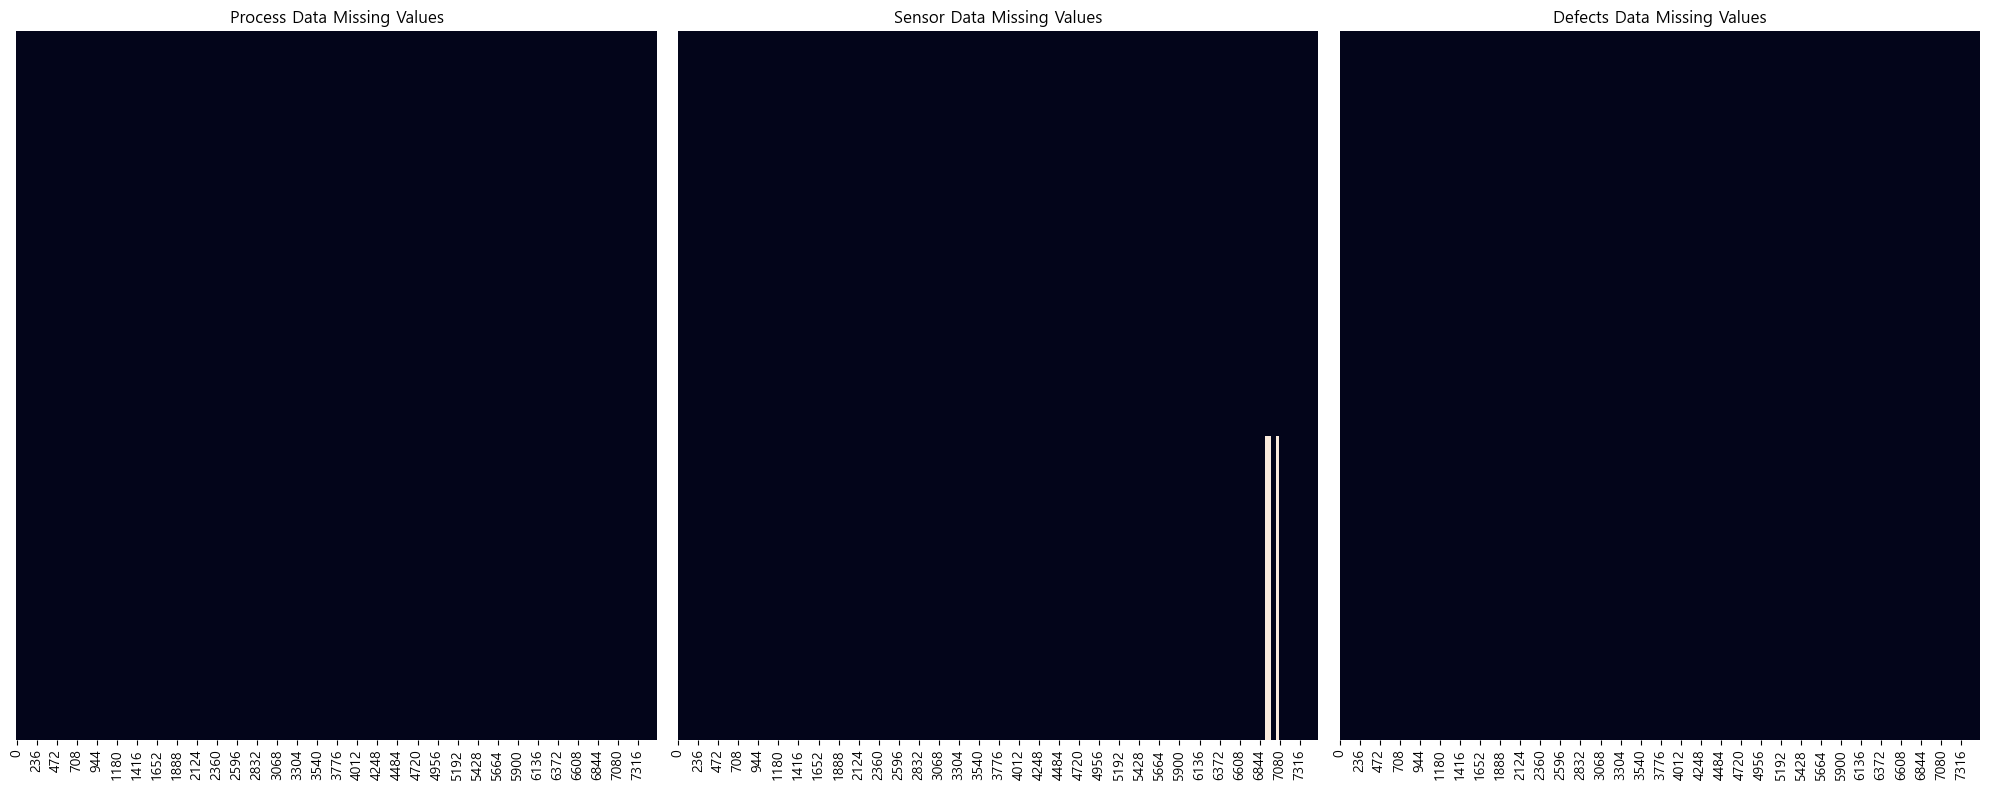

In [9]:
# 각 테이블의 결측치 시각화

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

sns.heatmap(df_process.isnull().T, cbar=False, yticklabels=False, ax=axes[0])
axes[0].set_title("Process Data Missing Values")

sns.heatmap(df_sensor.isnull().T, cbar=False, yticklabels=False, ax=axes[1])
axes[1].set_title("Sensor Data Missing Values")

sns.heatmap(df_defects.isnull().T, cbar=False, yticklabels=False, ax=axes[2])
axes[2].set_title("Defects Data Missing Values")

plt.tight_layout()
plt.show()

In [16]:
# 결측치가 있는 데이터 행 확인
nan_rows = df_sensor[df_sensor.isna().any(axis=1)]
display(nan_rows.head(30))

,melting_furnace_temp,air_pressure,air_pressure_min,air_pressure_max,coolant_temp,coolant_temp_min,coolant_temp_max,coolant_pressure,factory_temp,factory_temp_min,factory_temp_max,factory_humidity,factory_humidity_min,factory_humidity_max
6913,659.5,6.8,3,9,27.4,10,50,2.62,NaN,18.0,22.0,NaN,18.0,22.0
6914,659.5,6.8,3,9,27.4,10,50,2.62,NaN,18.0,22.0,NaN,18.0,22.0
6915,659.5,6.8,3,9,27.4,10,50,2.62,NaN,18.0,22.0,NaN,18.0,22.0
6916,659.5,6.8,3,9,27.4,10,50,2.62,NaN,18.0,22.0,NaN,18.0,22.0
6917,660.1,6.9,3,9,27.4,10,50,2.64,NaN,18.0,22.0,NaN,18.0,22.0
6918,660.1,6.9,3,9,27.4,10,50,2.64,NaN,18.0,22.0,NaN,18.0,22.0
6919,660.8,6.9,3,9,27.4,10,50,2.63,NaN,18.0,22.0,NaN,18.0,22.0
6920,660.8,6.9,3,9,27.4,10,50,2.63,NaN,18.0,22.0,NaN,18.0,22.0
6921,660.8,6.9,3,9,27.4,10,50,2.63,NaN,18.0,22.0,NaN,18.0,22.0
6922,660.8,6.9,3,9,27.4,10,50,2.63,NaN,18.0,22.0,NaN,18.0,22.0


In [19]:
nan_rows[["factory_temp", "factory_humidity"]].head(10)

,factory_temp,factory_humidity
6913,NaN,NaN
6914,NaN,NaN
6915,NaN,NaN
6916,NaN,NaN
6917,NaN,NaN
6918,NaN,NaN
6919,NaN,NaN
6920,NaN,NaN
6921,NaN,NaN
6922,NaN,NaN


### 선형 보간으로 온도, 습도를 채우기 전의 시각화 그래프

In [11]:
# 1. 최대/최소값 컬럼 결측치 채우기
# 전체 기간의 고정값으로 채우기
target_minmax_cols = [
    'factory_temp_max', 'factory_humidity_max', 
    'factory_humidity_min', 'factory_temp_min'
]
# 최빈값 기준
for col in target_minmax_cols:
    fill_value = df_sensor[col].mode()[0] 
    df_sensor[col] = df_sensor[col].fillna(fill_value)

# 3. 최종 결과 확인
print("결측치 처리 후 남은 개수:")
print(df_sensor[target_minmax_cols].isnull().sum())

결측치 처리 후 남은 개수:
factory_temp_max        0
factory_humidity_max    0
factory_humidity_min    0
factory_temp_min        0
dtype: int64


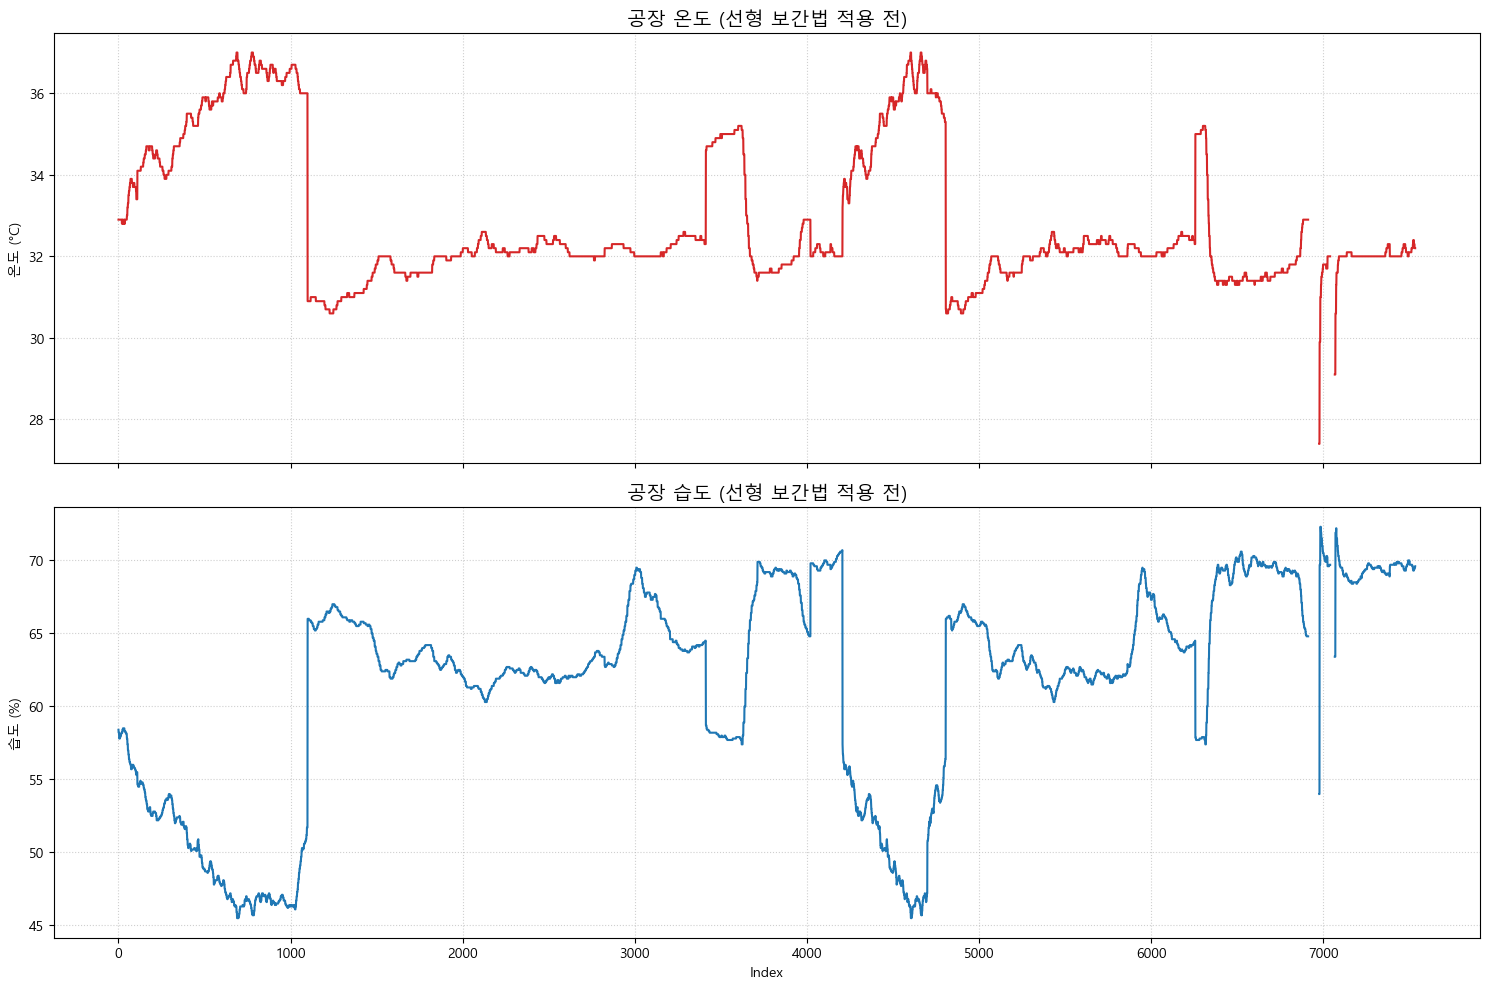

In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. 공장 온도 시각화

ax1.plot(df_sensor.index, df_sensor['factory_temp'], color='tab:red', linewidth=1.5)
ax1.set_title('공장 온도 (선형 보간법 적용 전)', fontsize=14)
ax1.set_ylabel('온도 (°C)')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. 공장 습도 시각화
ax2.plot(df_sensor.index, df_sensor['factory_humidity'], color='tab:blue', linewidth=1.5)
ax2.set_title('공장 습도 (선형 보간법 적용 전)', fontsize=14)
ax2.set_ylabel('습도 (%)')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.xlabel('Index')
plt.tight_layout()
plt.show()

In [22]:
# 선형 보간법으로 결측치 채우기

df_sensor['factory_temp'] = df_sensor['factory_temp'].interpolate(method='linear', limit_direction='both')
df_sensor['factory_humidity'] = df_sensor['factory_humidity'].interpolate(method='linear', limit_direction='both')

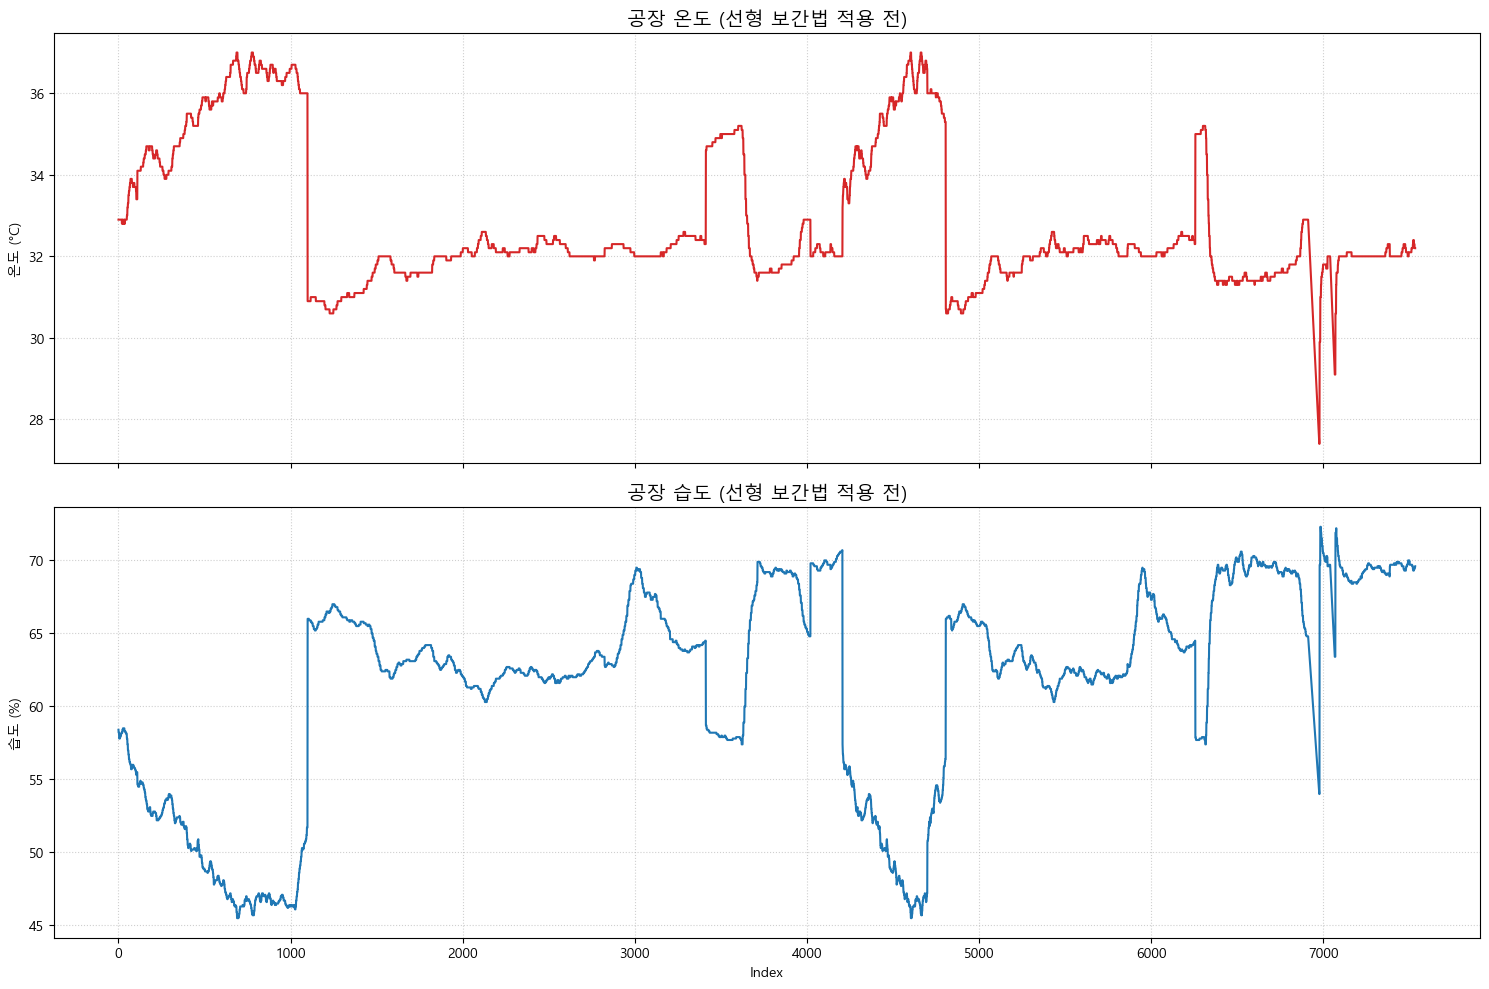

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. 공장 온도 시각화

ax1.plot(df_sensor.index, df_sensor['factory_temp'], color='tab:red', linewidth=1.5)
ax1.set_title('공장 온도 (선형 보간법 적용 후)', fontsize=14)
ax1.set_ylabel('온도 (°C)')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. 공장 습도 시각화
ax2.plot(df_sensor.index, df_sensor['factory_humidity'], color='tab:blue', linewidth=1.5)
ax2.set_title('공장 습도 (선형 보간법 적용 후)', fontsize=14)
ax2.set_ylabel('습도 (%)')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.xlabel('Index')
plt.tight_layout()
plt.show()

### 2.6 이상치 처리

In [25]:
# Process, Sensor 관련 데이터 확인
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"⬇️{df_name} 관련 데이터의 기초통계량⬇️")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기본 통계량
    stats_df = df_copied.describe().T
    
    # 고유값의 개수, 왜도, 첨도 추가
    stats_df['Unique'] = df_copied.nunique()
    stats_df['Skewness'] = df_copied.skew()
    stats_df['Kurtosis'] = df_copied.kurtosis()
    
    # 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수', # 결측치가 아닌 값의 개수
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Unique': '고유값',
        'Skewness': '왜도',
        'Kurtosis': '첨도'
    }, inplace=True)
    
    display(stats_df)
    
    return stats_df

In [26]:
# 함수 실행
stats_df_process = create_statistics_summary(df_process, 'Process', exclude_cols=['id', 'Product_Type', 'Shot'])
stats_df_sensor = create_statistics_summary(df_sensor, 'Sensor')


⬇️Process 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
product_type,7535.0,1.441672,0.496619,1.000,1.000,1.000,2.000,2.000,2,0.234962,-1.945309
shot,7535.0,453.798938,319.451698,0.000,195.000,401.000,645.000,1296.000,1271,0.700880,-0.281888
velocity_1,7535.0,0.148219,0.007134,0.134,0.142,0.144,0.156,0.180,33,0.638906,-0.689695
velocity_2,7535.0,0.168801,0.004720,0.158,0.166,0.168,0.170,0.212,27,4.087670,28.913573
velocity_3,7535.0,0.191193,0.011563,0.172,0.181,0.188,0.202,0.234,45,0.280346,-1.105678
high_velocity,7535.0,2.319210,0.222041,0.000,2.134,2.161,2.523,2.744,319,-0.347531,5.037868
cylinder_pressure,7535.0,239.655607,23.305451,107.000,217.000,239.000,265.000,266.000,22,-0.017856,-1.370291
rapid_rise_time,7535.0,0.009596,0.002148,0.000,0.008,0.009,0.012,0.021,18,0.332233,-0.359274
biscuit_thickness,7535.0,14.309622,3.286284,0.000,11.000,13.000,17.000,24.000,24,-0.012470,-0.446597
clamping_force,7535.0,306.433311,57.274965,238.000,255.000,258.000,372.000,388.000,42,0.272316,-1.872108



⬇️Sensor 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
melting_furnace_temp,7535.0,680.652661,25.288666,635.30,656.70,680.30,703.10,730.00,737,0.124036,-1.284874
air_pressure,7535.0,6.109595,0.647906,4.60,5.70,6.20,6.60,7.10,26,-0.480152,-0.673609
air_pressure_min,7535.0,3.000000,0.000000,3.00,3.00,3.00,3.00,3.00,1,0.000000,0.000000
air_pressure_max,7535.0,9.000000,0.000000,9.00,9.00,9.00,9.00,9.00,1,0.000000,0.000000
coolant_temp,7535.0,26.830126,0.525149,25.90,26.50,26.80,27.20,28.10,23,0.486100,-0.272945
coolant_temp_min,7535.0,10.000000,0.000000,10.00,10.00,10.00,10.00,10.00,1,0.000000,0.000000
coolant_temp_max,7535.0,50.000000,0.000000,50.00,50.00,50.00,50.00,50.00,1,0.000000,0.000000
coolant_pressure,7535.0,2.701155,0.052408,2.58,2.64,2.72,2.74,2.79,22,-0.571114,-1.100549
factory_temp,7535.0,32.799058,1.694920,27.40,31.80,32.10,33.70,37.00,156,1.030967,0.057630
factory_temp_min,7535.0,18.000000,0.000000,18.00,18.00,18.00,18.00,18.00,1,0.000000,0.000000


In [ ]:
import numpy as np
import pandas as pd

def detect_outliers_by_condition(df):
    outlier_indices = set()
    report = []

    # 1. 숫자형 컬럼에 대해 순회
    numeric_cols = df_process.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        series = df[col].dropna()
        if len(series) == 0: continue
        
        # 왜도와 첨도 계산
        skew = series.skew()
        kurt = series.kurt()
        
        # 2. 조건 확인: 왜도 |2| 미만 AND 첨도 |8| 미만
        if abs(skew) < 2 and abs(kurt) < 8:
            mean = series.mean()
            std = series.std()
            
            # Z-Score 계산 (3-Sigma 기준)
            z_scores = np.abs((df[col] - mean) / std)
            outliers = df[z_scores > 3]
            
            # 결과 리포트 저장
            report.append({
                "Column": col,
                "Skewness": round(skew, 2),
                "Kurtosis": round(kurt, 2),
                "Method": "Z-Score (Applied)",
                "Outlier Count": len(outliers)
            })